In [2]:
del state
del clip
del promptoptim
del vqgan
del processor
import gc
gc.collect()
torch.cuda.empty_cache()

NameError: name 'torch' is not defined

In [1]:
import os
import torch
import sys
import matplotlib.pyplot as plt
sys.path.append("taming-transformers")
import functools
import edit
import importlib
import app_backend
importlib.reload(app_backend)
from app_backend import ProcessorGradientFlow, ImagePromptOptimizer, ImageState
from transformers import CLIPProcessor, CLIPModel
from loaders import load_default
import gradio as gr
device = "cuda"
vqgan = load_default(device)
vqgan.eval()
processor = ProcessorGradientFlow(device=device)
clip = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
clip.to(device)

print('done')

/opt/conda/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Working with z of shape (1, 256, 16, 16) = 65536 dimensions.
done


In [ ]:
plt.imshow(x)

In [ ]:
def rescale_mask(mask):
  rep = mask.clone()
  rep[mask < 0.03] = -1000000
  rep[mask >= 0.03] = 1
  return mask

In [ ]:
plt.imshow()

In [2]:
import torch
from app_backend import get_resized_tensor
device="cuda"
mask = torch.load("nose_mask.pt", map_location=device)
# print(get_resized_tensor(mask))

torch.Size([256, 256])


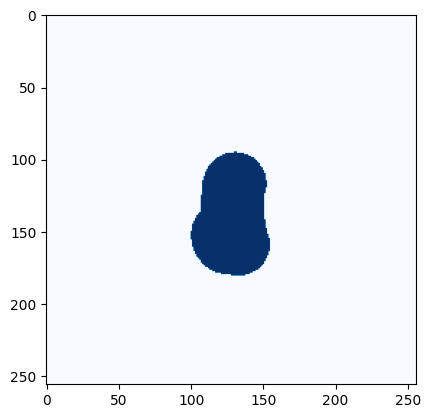

In [5]:
print(mask.shape)
plt.imshow(mask.cpu(), cmap="Blues")


odict_keys(['main.0.weight', 'main.0.bias', 'main.2.weight', 'main.3.weight', 'main.3.bias', 'main.3.running_mean', 'main.3.running_var', 'main.3.num_batches_tracked', 'main.5.weight', 'main.6.weight', 'main.6.bias', 'main.6.running_mean', 'main.6.running_var', 'main.6.num_batches_tracked', 'main.8.weight', 'main.9.weight', 'main.9.bias', 'main.9.running_mean', 'main.9.running_var', 'main.9.num_batches_tracked', 'main.11.weight', 'main.11.bias'])
Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


/opt/conda/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /opt/conda/lib/python3.9/site-packages/lpips/weights/v0.1/vgg.pth


/opt/conda/lib/python3.9/site-packages/torchvision/transforms/functional.py:442: UserWarning: Argument 'interpolation' of type int is deprecated since 0.13 and will be removed in 0.15. Please use InterpolationMode enum.
  warnings.warn(


mask in apply  tensor([[[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 1., 1., 0., 0., 0., 0.],
         [0., 0., 0., 0., 1., 1., 0., 0., 0., 0.],
         [0., 0., 0., 0., 1., 1., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]]], device='cuda:0') torch.Size([1, 10, 10])


  0%|          | 0/15 [00:00<?, ?it/s]

CLIP loss tensor(0.0366, device='cuda:0', grad_fn=<AddBackward0>)
LPIPS loss:  tensor([[[[0.9434]]]], device='cuda:0', dtype=torch.float16,
       grad_fn=<MulBackward0>)
disc_loss = 0.08587646484375
Sum Loss tensor([[[[0.9800]]]], device='cuda:0', dtype=torch.float16,
       grad_fn=<AddBackward0>)


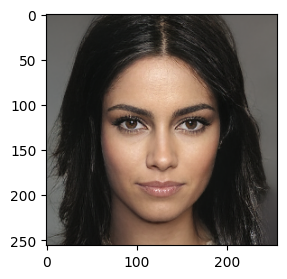

  7%|▋         | 1/15 [00:01<00:14,  1.07s/it]

CLIP loss tensor(0.0448, device='cuda:0', grad_fn=<AddBackward0>)
LPIPS loss:  tensor([[[[1.7539]]]], device='cuda:0', dtype=torch.float16,
       grad_fn=<MulBackward0>)
disc_loss = 0.08612060546875
Sum Loss tensor([[[[1.7988]]]], device='cuda:0', dtype=torch.float16,
       grad_fn=<AddBackward0>)


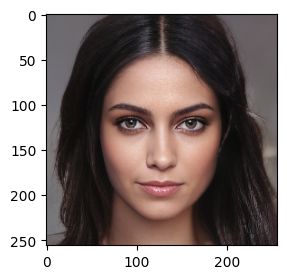

 13%|█▎        | 2/15 [00:01<00:11,  1.16it/s]

CLIP loss tensor(0.0394, device='cuda:0', grad_fn=<AddBackward0>)
LPIPS loss:  tensor([[[[1.4434]]]], device='cuda:0', dtype=torch.float16,
       grad_fn=<MulBackward0>)
disc_loss = 0.08599853515625
Sum Loss tensor([[[[1.4824]]]], device='cuda:0', dtype=torch.float16,
       grad_fn=<AddBackward0>)


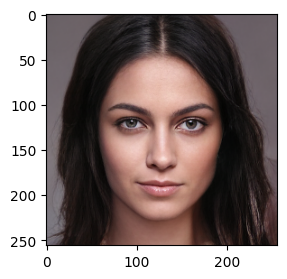

 20%|██        | 3/15 [00:02<00:09,  1.24it/s]

CLIP loss tensor(0.0342, device='cuda:0', grad_fn=<AddBackward0>)
LPIPS loss:  tensor([[[[1.3340]]]], device='cuda:0', dtype=torch.float16,
       grad_fn=<MulBackward0>)
disc_loss = 0.086181640625
Sum Loss tensor([[[[1.3682]]]], device='cuda:0', dtype=torch.float16,
       grad_fn=<AddBackward0>)


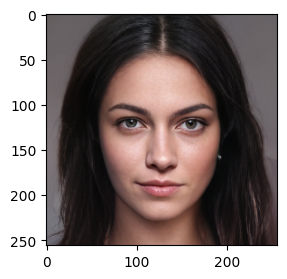

 27%|██▋       | 4/15 [00:03<00:08,  1.30it/s]

CLIP loss tensor(0.0243, device='cuda:0', grad_fn=<AddBackward0>)
LPIPS loss:  tensor([[[[1.2305]]]], device='cuda:0', dtype=torch.float16,
       grad_fn=<MulBackward0>)
disc_loss = 0.0863037109375
Sum Loss tensor([[[[1.2549]]]], device='cuda:0', dtype=torch.float16,
       grad_fn=<AddBackward0>)


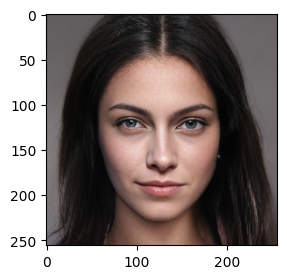

 33%|███▎      | 5/15 [00:03<00:07,  1.33it/s]

CLIP loss tensor(0.0318, device='cuda:0', grad_fn=<AddBackward0>)
LPIPS loss:  tensor([[[[1.2275]]]], device='cuda:0', dtype=torch.float16,
       grad_fn=<MulBackward0>)
disc_loss = 0.08587646484375
Sum Loss tensor([[[[1.2598]]]], device='cuda:0', dtype=torch.float16,
       grad_fn=<AddBackward0>)


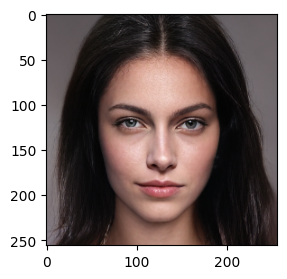

 40%|████      | 6/15 [00:04<00:06,  1.35it/s]

CLIP loss tensor(0.0211, device='cuda:0', grad_fn=<AddBackward0>)
LPIPS loss:  tensor([[[[1.1787]]]], device='cuda:0', dtype=torch.float16,
       grad_fn=<MulBackward0>)
disc_loss = 0.08612060546875
Sum Loss tensor([[[[1.2002]]]], device='cuda:0', dtype=torch.float16,
       grad_fn=<AddBackward0>)


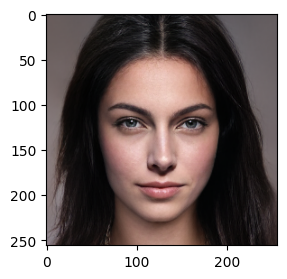

 47%|████▋     | 7/15 [00:05<00:05,  1.36it/s]

CLIP loss tensor(0.0065, device='cuda:0', grad_fn=<AddBackward0>)
LPIPS loss:  tensor([[[[1.1123]]]], device='cuda:0', dtype=torch.float16,
       grad_fn=<MulBackward0>)
disc_loss = 0.08587646484375
Sum Loss tensor([[[[1.1191]]]], device='cuda:0', dtype=torch.float16,
       grad_fn=<AddBackward0>)


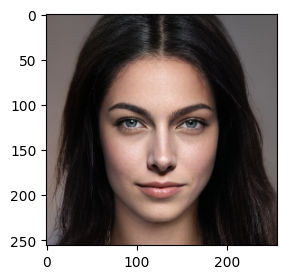

 53%|█████▎    | 8/15 [00:06<00:05,  1.37it/s]

CLIP loss tensor(0.0055, device='cuda:0', grad_fn=<AddBackward0>)
LPIPS loss:  tensor([[[[1.0811]]]], device='cuda:0', dtype=torch.float16,
       grad_fn=<MulBackward0>)
disc_loss = 0.08563232421875
Sum Loss tensor([[[[1.0869]]]], device='cuda:0', dtype=torch.float16,
       grad_fn=<AddBackward0>)


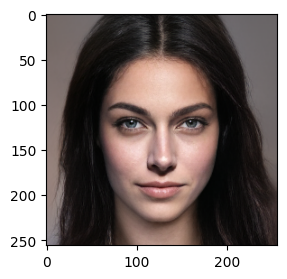

 60%|██████    | 9/15 [00:06<00:04,  1.35it/s]

CLIP loss tensor(0.0043, device='cuda:0', grad_fn=<AddBackward0>)
LPIPS loss:  tensor([[[[1.0713]]]], device='cuda:0', dtype=torch.float16,
       grad_fn=<MulBackward0>)
disc_loss = 0.0850830078125
Sum Loss tensor([[[[1.0752]]]], device='cuda:0', dtype=torch.float16,
       grad_fn=<AddBackward0>)


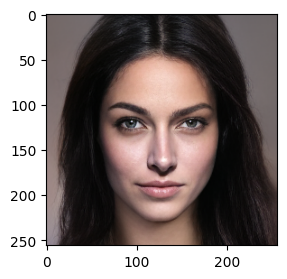

 67%|██████▋   | 10/15 [00:07<00:03,  1.37it/s]

CLIP loss tensor(-0.0117, device='cuda:0', grad_fn=<AddBackward0>)
LPIPS loss:  tensor([[[[1.0264]]]], device='cuda:0', dtype=torch.float16,
       grad_fn=<MulBackward0>)
disc_loss = 0.0850830078125
Sum Loss tensor([[[[1.0146]]]], device='cuda:0', dtype=torch.float16,
       grad_fn=<AddBackward0>)


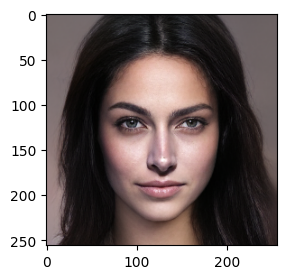

 73%|███████▎  | 11/15 [00:08<00:02,  1.38it/s]

CLIP loss tensor(-0.0089, device='cuda:0', grad_fn=<AddBackward0>)
LPIPS loss:  tensor([[[[1.0039]]]], device='cuda:0', dtype=torch.float16,
       grad_fn=<MulBackward0>)
disc_loss = 0.08489990234375
Sum Loss tensor([[[[0.9951]]]], device='cuda:0', dtype=torch.float16,
       grad_fn=<AddBackward0>)


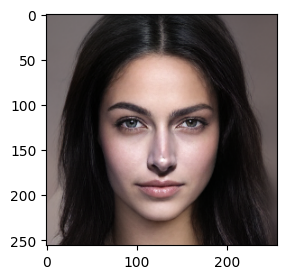

 80%|████████  | 12/15 [00:09<00:02,  1.38it/s]

CLIP loss tensor(-0.0127, device='cuda:0', grad_fn=<AddBackward0>)
LPIPS loss:  tensor([[[[1.0156]]]], device='cuda:0', dtype=torch.float16,
       grad_fn=<MulBackward0>)
disc_loss = 0.08551025390625
Sum Loss tensor([[[[1.0029]]]], device='cuda:0', dtype=torch.float16,
       grad_fn=<AddBackward0>)


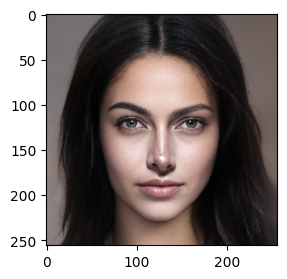

 87%|████████▋ | 13/15 [00:09<00:01,  1.40it/s]

CLIP loss tensor(-0.0117, device='cuda:0', grad_fn=<AddBackward0>)
LPIPS loss:  tensor([[[[0.9883]]]], device='cuda:0', dtype=torch.float16,
       grad_fn=<MulBackward0>)
disc_loss = 0.08538818359375
Sum Loss tensor([[[[0.9766]]]], device='cuda:0', dtype=torch.float16,
       grad_fn=<AddBackward0>)


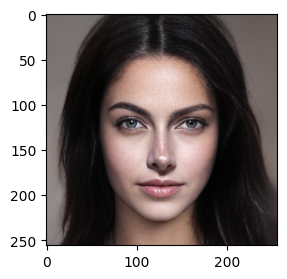

 93%|█████████▎| 14/15 [00:10<00:00,  1.41it/s]

CLIP loss tensor(-0.0200, device='cuda:0', grad_fn=<AddBackward0>)
LPIPS loss:  tensor([[[[0.9688]]]], device='cuda:0', dtype=torch.float16,
       grad_fn=<MulBackward0>)
disc_loss = 0.08514404296875
Sum Loss tensor([[[[0.9487]]]], device='cuda:0', dtype=torch.float16,
       grad_fn=<AddBackward0>)


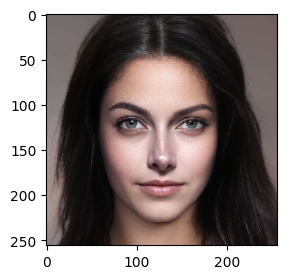

100%|██████████| 15/15 [00:11<00:00,  1.35it/s]


lpips solo op
disc_loss = 0.08551025390625
LPIPS loss:  tensor([[[[0.9453]]]], device='cuda:0', dtype=torch.float16,
       grad_fn=<MulBackward0>)


RuntimeError: hook 'attn_masking2' has changed the type of value (was torch.cuda.HalfTensor got torch.cuda.FloatTensor)

In [3]:
# from icecream import ic
# ic.disable()
promptoptim = ImagePromptOptimizer(vqgan, clip, processor, lpips_weight=25., quantize=True)
state = ImageState(vqgan, promptoptim)
x = state.blend("./test_data/face.jpeg", "./test_data/face2.jpeg", 0.5)
torch.manual_seed(10)
mask = torch.load("nose_mask.pt", map_location=device)
from img_processing import custom_to_pil
no_mask=torch.ones_like(mask)
# mask = rescale_mask(mask)
# mask *= 1
pos_prompts = "a picture of a woman with very big wide nose"
neg_prompts = "a picture of a person with a small thin nose"
for i, pic in enumerate(state.apply_prompts(pos_prompts, neg_prompts, 0.61, 15, None, 10., 10, mask=mask)):
    plt.figure(figsize=(3, 3))
    plt.imshow(pic)
    plt.show()

In [ ]:
import os
import sys
sys.path.append("taming-transformers")
import functools
import edit
# import importlib
# importlib.reload(edit)
from app_backend import ProcessorGradientFlow, ImagePromptOptimizer, ImageState
from transformers import CLIPProcessor, CLIPModel
from loaders import load_default
import gradio as gr
device = "cuda"
vqgan = load_default(device)
vqgan.eval()
processor = ProcessorGradientFlow(device=device)
clip = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
clip.to(device)
promptoptim = ImagePromptOptimizer(vqgan, clip, processor, quantize=True)
state = ImageState(vqgan, promptoptim)

with gr.Blocks() as demo:
    with gr.Row():
        with gr.Column(scale=2):
            hair_red_blue = gr.Slider(
                label="hair red<->blue ",
                minimum=-.8,
                maximum=.8,
                value=0,
                step=0.1,
            )
            hair_green_purple = gr.Slider(
                label="hair green<->purple ",
                minimum=-.8,
                maximum=.8,
                value=0,
                step=0.1,
            )
            lip_size = gr.Slider(
                label="lip size",
                minimum=-1.9,
                value=0,
                maximum=1.9,
                step=0.1,
            )
            blend_weight = gr.Slider(
                label="0 is src image, 1 is blend_img",
                minimum=-0.,
                value=0,
                maximum=1.,
                step=0.1,
            )
            requantize = gr.Checkbox(
                label="requantize latents",
                value=True,
            )
            gender_weight = gr.Slider(
                label="gender weight (-1 female, 1 male)",
                minimum=-2.,
                value=0,
                maximum=2.,
                step=0.07,
            )
            with gr.Row():
                with gr.Column(scale=1):
                    base_img = gr.Image(label="base Image", type="filepath")
                    blend_img = gr.Image(label="image for face blending (optional)", type="filepath")
                with gr.Column(scale=2):
                    positive_prompts = gr.Textbox(label="Positive prompts")
                    negative_prompts = gr.Textbox(label="Negative prompts")
                    iterations = gr.Slider(minimum=10,
                                            maximum=300,
                                            value=40,
                                            label="optimization iterations",)
                    learning_rate = gr.Slider(minimum=1e-3,
                                            maximum=1e-1,
                                            value=1e-2,
                                            label="learning rate")
                    lpips_weight = gr.Slider(minimum=0,
                                            maximum=30,
                                            value=0,
                                            label="Perceptual similarity (high to preserve identity for transformations where the person's identity should not change, recommended when masking)")
                    apply_prompts = gr.Button(value="Apply Prompts")

        with gr.Column(scale=1):
            out = gr.Image(interactive=True, tool="sketch", shape=(200, 200))
            test = gr.Image(interactive=False, shape=(200, 200))
            i = gr.Button()
    gender_weight.change(state.apply_gender_vector, inputs=[gender_weight], outputs=out)
    requantize.change(state.update_requant, inputs=[requantize], outputs=out)
    lip_size.change(state.apply_lip_vector, inputs=[lip_size], outputs=out)
    hair_green_purple.change(state.apply_gp_vector, inputs=[hair_green_purple], outputs=out)
    hair_red_blue.change(state.apply_rb_vector, inputs=[hair_red_blue], outputs=out)
    blend_weight.change(state.blend, inputs=[base_img, blend_img, blend_weight], outputs=out)
    base_img.change(state.blend, inputs=[base_img, base_img, blend_weight], outputs=out)
    blend_img.change(state.blend, inputs=[base_img, blend_img, blend_weight], outputs=out)
    apply_prompts.click(state.apply_prompts, inputs=[positive_prompts, negative_prompts, learning_rate, iterations, out, lpips_weight], outputs=out)
if __name__ == "__main__":
    demo.queue()
    demo.launch(share=True, debug=True, inbrowser=True)


In [ ]:
plt.imshow(x)
plt.show()

In [ ]:
!git commit -m "uipdate backend"

In [ ]:
mask.shape

In [ ]:
!git config --global user.email "you@example.com"
!git config --global user.name "Your Name"

In [ ]:
!git stash
!git pull

In [ ]:
torch.manual_seed(10)
mask = torch.load("lip_mask.pt")
from img_processing import custom_to_pil
no_mask=torch.ones_like(mask)
# mask = rescale_mask(mask) * -1
# mask *= -1
# mask = no_mask
pos_prompts = ["a picture of a woman with bright red lipstick"]
neg_prompts = ["a picture of an ugly person", " a picture of a person not wearing makeup",]
for i, pic in enumerate(state.apply_prompts(pos_prompts, neg_prompts, 0.02, 40, None, mask=mask)):
  plt.imshow(pic)
  plt.show()

In [ ]:
# mask.shape
# import torchvision
mask = torch.load("eyebrow_mask.pt")

t = mask.unsqueeze(0)
test = torchvision.transforms.functional.resize(t, (10, 10))


In [ ]:
print(test)

In [ ]:
print(test)
# rep = test[test==0] = -100

In [ ]:
rep = test.clone()
rep[test < 0.03] = -100
rep[test >= 0.03] = 100
print(rep)

# rep[test!=0] = 5

In [ ]:
!git pull

In [ ]:
import torchvision
from transformers import CLIPProcessor, CLIPModel
class ProcessorGradientFlow():
    def __init__(self, device="cuda") -> None:
        self.device = device
        self.processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
        self.image_mean = [0.48145466, 0.4578275, 0.40821073]
        self.image_std = [0.26862954, 0.26130258, 0.27577711]
        self.normalize = torchvision.transforms.Normalize(
            self.image_mean,
            self.image_std
        )
        self.resize = torchvision.transforms.Resize(224)
        self.center_crop = torchvision.transforms.CenterCrop(224)
    def preprocess_img(self, images):
        images = self.center_crop(images)
        images = self.resize(images)
        images = self.center_crop(images)
        images = self.normalize(images)
        return images
    def __call__(self, images=[], **kwargs):
        processed_inputs = self.processor(**kwargs)
        processed_inputs["pixel_values"] = self.preprocess_img(images)
        processed_inputs = {key:value.to(self.device) for (key, value) in processed_inputs.items()}
        return processed_inputs

In [ ]:
processor = ProcessorGradientFlow()
clip = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
clip.to(device)

In [ ]:
import torch.nn as nn
from img_processing import *
from utils import freeze_module
import matplotlib.pyplot as plt
from tqdm import tqdm
class ImagePromptOptimizer(nn.Module):
    def __init__(self, 
                vqgan, 
                clip,
                clip_preprocessor,
                iterations=100,
                lr = 0.01,
                save_vector=True,
                return_val="latent",
                quantize=True,
                make_grid=False) -> None:
                
        super().__init__()
        self.latent = None
        self.device = vqgan.device
        vqgan.eval()
        self.vqgan = vqgan
        self.clip = clip
        self.iterations = iterations
        self.lr = lr
        self.clip_preprocessor = clip_preprocessor
        self.make_grid = make_grid
        self.return_val = return_val
        self.quantize = quantize
    def set_latent(self, latent):
        self.latent = latent.detach().to(self.device)
    def set_params(self, lr, iterations, attn_mask):
        self.attn_mask = attn_mask
        self.iterations = iterations
        self.lr = lr
    def forward(self, vector):
        base_latent = self.latent.detach().requires_grad_()
        trans_latent = base_latent + vector
        if self.quantize:
          z_q, *_ = self.vqgan.quantize(trans_latent)
        else:
          z_q = trans_latent
        dec = self.vqgan.decode(z_q)
        return dec
    def _get_clip_similarity(self, prompts, image, weights=None):
        if isinstance(prompts, str):
            prompts = [prompts]
        elif not isinstance(prompts, list):
            raise TypeError("Provide prompts as string or list of strings")
        clip_inputs = self.clip_preprocessor(text=prompts,
            images=image, return_tensors="pt", padding=True)
        clip_outputs = self.clip(**clip_inputs)
        similarity_logits = clip_outputs.logits_per_image
        if weights:
            similarity_logits *= weights
        return similarity_logits.sum()
    def get_similarity_loss(self, pos_prompts, neg_prompts, image):
        pos_logits = self._get_clip_similarity(pos_prompts, image)
        if neg_prompts:
            neg_logits = self._get_clip_similarity(neg_prompts, image)
        else:
            neg_logits = torch.tensor([0], device=self.device)
        loss = -torch.log(pos_logits) + torch.log(neg_logits)
        return loss
    def visualize(self, processed_img):
        if self.make_grid:
            self.index += 1
            plt.subplot(1, 9, self.index)
            plt.imshow(get_pil(processed_img[0]).detach().cpu())
        else:
            plt.imshow(get_pil(processed_img[0]).detach().cpu())
            plt.show()
    def optimize(self, latent, pos_prompts, neg_prompts):
        self.set_latent(latent)
        vector = torch.randn_like(self.latent, requires_grad=True, device=self.device)
        optim = torch.optim.Adam([vector], lr=self.lr)
        if self.make_grid:
            plt.figure(figsize=(35, 25))
            self.index = 1
        for i in tqdm(range(self.iterations)):
            transformed_img = self(vector)
            processed_img = loop_post_process(transformed_img).retain_grad()
            p1 = processed_img.retain_grad().grad
            print(p1)
            loss = self.get_similarity_loss(pos_prompts, neg_prompts, processed_img)
            optim.zero_grad()
            # p2 = processed_img.grad
            # print(p2)
            loss.backward()
            p3 = processed_img.retain_grad().grad
            print(p3, p3.shape)
            optim.step()
            return
            # if i % self.iterations // 10 == 0: 
                # self.visualize(processed_img)
            yield vector
        # if self.make_grid:
            # plt.savefig(f"plot {pos_prompts[0]}.png")
            # plt.show()
        # yield vector if self.return_val == "vector" else self.latent + vector

In [ ]:
clip.device

In [ ]:
from img_processing import custom_to_pil
import edit
importlib.reload(edit)
from edit import blend_paths
class ImageState:
    def __init__(self, vqgan, prompt_optimizer: ImagePromptOptimizer) -> None:
        self.vqgan = vqgan
        self.device = vqgan.device
        #latentvectors
        self.lip_vector = torch.load("./latent_vectors/lipvector.pt", map_location=self.device)
        self.red_blue_vector = torch.load("./latent_vectors/red_blue.pt", map_location=self.device)
        self.green_purple_vector = torch.load("./latent_vectors/green_purple.pt", map_location=self.device)
        # self.gender_vector = torch.load("./latent_vectors/gender.pt")
        self.asian_vector = torch.load("./latent_vectors/asian10.pt", map_location=self.device)
        #latent transforms
        self.hair_rb = torch.zeros_like(self.lip_vector)
        self.lip_transforms = torch.zeros_like(self.lip_vector)
        self.gender_transforms = torch.zeros_like(self.lip_vector)
        self.prompt_transforms = torch.zeros_like(self.lip_vector) 
        self.hair_gp = torch.zeros_like(self.lip_vector)
        self.blend_latent = None
        self.quant = True
        self.prompt_optim = prompt_optimizer
    def _apply_vector(self, src, vector):
        new_latent = torch.lerp(src, src + vector, 1)
        return new_latent
    def _decode_latent(self, latent):
        current_im = self.vqgan.decode(latent.to(self.device))[0]
        return custom_to_pil(current_im)
    def _render_all_transformations(self):
        self.current_vector_transforms = [self.hair_rb, self.lip_transforms, self.hair_gp, self.gender_transforms, self.prompt_transforms]
        new_latent = self.blend_latent + sum(self.current_vector_transforms).to(self.device)
        if self.quant:
            new_latent, _, _ = self.vqgan.quantize(new_latent.to(self.device))
        return self._decode_latent(new_latent)
    def apply_gp_vector(self, weight):
        self.hair_gp = weight * self.green_purple_vector
        return self._render_all_transformations()
    def apply_rb_vector(self, weight):
        self.hair_rb = weight * self.red_blue_vector
        return self._render_all_transformations()
    def apply_lip_vector(self, weight):
        self.lip_transforms = weight * self.lip_vector
        return self._render_all_transformations()
    def update_requant(self, val):
        print(f"val = {val}")
        self.quant = val
        return self._render_all_transformations()
    def apply_gender_vector(self, weight):
        self.gender_transforms = weight * self.asian_vector
        return self._render_all_transformations()
    def blend(self, path1, path2, weight):
        img, latent = blend_paths(self.vqgan, path1, path2, weight=weight, show=False, device=self.device)
        self.blend_latent = latent.to(self.device)
        return self._render_all_transformations()
    def apply_prompts(self, positive_prompts, negative_prompts, lr, iterations, img):
        attn_mask = img["mask"]
        print(type(attn_mask))
        print(attn_mask.shape)
        self.prompt_optim.set_params(lr, iterations, attn_mask)
        for i, transform in enumerate(self.prompt_optim.optimize(self.blend_latent,
                                                positive_prompts,
                                                negative_prompts)):
          
          print(i)
          self.prompt_transforms = transform
          yield self._render_all_transformations()
        # transform = self.prompt_optim.optimize(self.blend_latent,
                                                # positive_prompts,
                                                # negative_prompts)
        # self.prompt_transforms = transform
        # return self._render_all_transformations()

In [ ]:
promptoptim = ImagePromptOptimizer(vqgan, clip, processor, quantize=False)
test = ImageState(vqgan, promptoptim)
test.blend("./test_data/face.jpeg", "./test_data/face2.jpeg", 0.5)
test.apply_lip_vector(0.6)

In [ ]:
test.apply_rb_vector(.8)

In [ ]:
test.apply_lip_vector(.6)

In [ ]:
test.blend("./test_data/face.jpeg", "./test_data/face2.jpeg", 0.1)

In [ ]:
!git pull

In [ ]:
# %load_ext gradio

In [ ]:
del state
del clip
del promptoptim
del vqgan
del processor
import gc
gc.collect()
torch.cuda.empty_cache()

In [ ]:
%tb